# Data Prep

* View data_prep folder and pipeline file for detailed info
* Parameter to change on new Data: constants.py with cols and paths,
also fail_on_duplcate must be set to true if duplicated values are viewed to be an error (timestamps are always errors).

In [38]:
print("test")

test


In [39]:
from pathlib import Path
import sys

# Ensure the project src/ directory is importable from the notebook.
_cwd = Path.cwd().resolve()
PROJECT_ROOT = next(
    p for p in [_cwd, *_cwd.parents] if (p / "src" / "timeseries_forecast").exists()
)
SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from timeseries_forecast.data_prep.raw_data import read_raw_metals_data
from timeseries_forecast.data_prep.pipeline import run_data_pipeline
from timeseries_forecast.data_prep.data_merge import merge_all_raw_data
from timeseries_forecast.data_prep.constants import RawMetalsColumn

# from timeseries_forecast.feature import autoregressive_features
# from timeseries_forecast.eval.eval import evaluate, evaluate_predictions
# from timeseries_forecast.feature.custom_features import add_log_ret_features
# from timeseries_forecast.feature import engineer_features
# from timeseries_forecast.config.feature_config import FeatureConfig
from timeseries_forecast.data_prep.data_resample import resample_dataframe_with_aggregations

In [40]:
alu_df = read_raw_metals_data("aluminium")
alu_df.Date

0      2024-08-29
1      2024-08-28
2      2024-08-27
3      2024-08-26
4      2024-08-23
          ...    
2730   2014-01-07
2731   2014-01-06
2732   2014-01-03
2733   2014-01-02
2734   2014-01-01
Name: Date, Length: 2735, dtype: datetime64[us]

## Cleaning for all metals with same parameters

### Aluminium

In [41]:
aluminium_df_cleaned = run_data_pipeline(
    read_raw_metals_data("aluminium"),
    timestamp_column=RawMetalsColumn.OPEN_TIME,
    data_freq="D",
    split_train_end="2019-12-31",
    split_val_end="2021-12-31",
    zero_value_ignore_cols=[RawMetalsColumn.PCT_CHANGE],
    zero_as_nan_cols=[RawMetalsColumn.VOLUME],
).rename(columns={RawMetalsColumn.PRICE: "Close"}).drop(columns=[RawMetalsColumn.PCT_CHANGE])
aluminium_df_cleaned


Duplikat-Check
OK: Keine doppelten Zeitstempel im Index
WARN: 4 Zeilen sind doppelt (identischer Inhalt)
  Beispiele (erste 5 Timestamps):
DatetimeIndex(['2020-09-29', '2020-09-30', '2024-07-30', '2024-07-31'], dtype='datetime64[us]', name='RawMetalsColumn.OPEN_TIME', freq=None)

Fehlende Werte Check
WARN: Es gibt 1159 Lücken in der Zeitreihe (erwartete Frequenz: D).

NaN-Check
WARN: 15 NaN-Werte insgesamt gefunden:
  Vol.: 15 (0.55%)

0-Werte Check
WARN: 32 0-Werte insgesamt gefunden:
  Vol.: 32 (1.17%)

Data Cleaning – Interpolation von Missing Values und Nullwerten

  Vollständiger Zeitindex: 3,894 Einträge
  Aktueller DataFrame:    2,735 Zeilen
  Zu ergänzende Einträge: 1,159
    RawMetalsColumn.VOLUME: 32 Nullwerte -> NaN ersetzt

  Interpoliere 6 numerische Spalten:
    Price: 1159 -> 0 NaN
    Open: 1159 -> 0 NaN
    High: 1159 -> 0 NaN
    Low: 1159 -> 0 NaN
    Vol.: 1206 -> 0 NaN
    Change %: 1159 -> 0 NaN

  Shape vorher:  (2735, 6)
  Shape nachher: (3894, 6)
OK: Interpola

,Close,Open,High,Low,Vol.,Mode
2014-01-01,110.10,110.000000,110.700000,109.900000,450.000000,Train
2014-01-02,111.20,110.550000,112.200000,110.450000,4720.000000,Train
2014-01-03,109.20,110.900000,111.100000,109.050000,4520.000000,Train
2014-01-04,109.35,110.433333,110.650000,108.733333,4333.333333,Train
2014-01-05,109.50,109.966667,110.200000,108.416667,4146.666667,Train
...,...,...,...,...,...,...
2024-08-25,229.60,229.450000,232.433333,227.483333,1236.666667,Test
2024-08-26,229.50,230.850000,233.500000,228.850000,510.000000,Test
2024-08-27,231.55,229.000000,233.000000,228.200000,60.000000,Test
2024-08-28,232.05,233.400000,233.400000,231.400000,35.000000,Test


In [42]:
# alu_df_cleaned.loc["25-08-2024"]

### Copper

In [43]:
copper_df_cleaned = run_data_pipeline(
    read_raw_metals_data("copper"),
    timestamp_column=RawMetalsColumn.OPEN_TIME,
    data_freq="D",
    split_train_end="2019-12-31",
    split_val_end="2021-12-31",
    zero_value_ignore_cols=[RawMetalsColumn.PCT_CHANGE],
    zero_as_nan_cols=[RawMetalsColumn.VOLUME],
).rename(columns={RawMetalsColumn.PRICE: "Close"}).drop(columns=[RawMetalsColumn.PCT_CHANGE])


Duplikat-Check
OK: Keine doppelten Zeitstempel im Index
OK: Keine identischen Zeilenduplikate gefunden

Fehlende Werte Check
WARN: Es gibt 1136 Lücken in der Zeitreihe (erwartete Frequenz: D).

NaN-Check
WARN: 20 NaN-Werte insgesamt gefunden:
  Vol.: 20 (0.73%)

0-Werte Check
WARN: 5 0-Werte insgesamt gefunden:
  Vol.: 5 (0.18%)

Data Cleaning – Interpolation von Missing Values und Nullwerten

  Vollständiger Zeitindex: 3,894 Einträge
  Aktueller DataFrame:    2,758 Zeilen
  Zu ergänzende Einträge: 1,136
    RawMetalsColumn.VOLUME: 5 Nullwerte -> NaN ersetzt

  Interpoliere 6 numerische Spalten:
    Price: 1136 -> 0 NaN
    Open: 1136 -> 0 NaN
    High: 1136 -> 0 NaN
    Low: 1136 -> 0 NaN
    Vol.: 1161 -> 0 NaN
    Change %: 1136 -> 0 NaN

  Shape vorher:  (2758, 6)
  Shape nachher: (3894, 6)
OK: Interpolation abgeschlossen!

Duplikat-Check
OK: Keine doppelten Zeitstempel im Index
OK: Keine identischen Zeilenduplikate gefunden

Fehlende Werte Check
OK: Keine Lücken in der Zeitreihe 

### gold

In [44]:
gold_df_cleaned = run_data_pipeline(
    read_raw_metals_data("gold"),
    timestamp_column=RawMetalsColumn.OPEN_TIME,
    data_freq="D",
    split_train_end="2019-12-31",
    split_val_end="2021-12-31",
    zero_value_ignore_cols=[RawMetalsColumn.PCT_CHANGE],
    zero_as_nan_cols=[RawMetalsColumn.VOLUME],
).rename(columns={RawMetalsColumn.PRICE: "Close"}).drop(columns=[RawMetalsColumn.PCT_CHANGE])


Duplikat-Check
OK: Keine doppelten Zeitstempel im Index
OK: Keine identischen Zeilenduplikate gefunden

Fehlende Werte Check
WARN: Es gibt 1135 Lücken in der Zeitreihe (erwartete Frequenz: D).

NaN-Check
WARN: 22 NaN-Werte insgesamt gefunden:
  Vol.: 22 (0.80%)

0-Werte Check
WARN: 7 0-Werte insgesamt gefunden:
  Vol.: 7 (0.25%)

Data Cleaning – Interpolation von Missing Values und Nullwerten

  Vollständiger Zeitindex: 3,895 Einträge
  Aktueller DataFrame:    2,760 Zeilen
  Zu ergänzende Einträge: 1,135
    RawMetalsColumn.VOLUME: 7 Nullwerte -> NaN ersetzt

  Interpoliere 6 numerische Spalten:
    Price: 1135 -> 0 NaN
    Open: 1135 -> 0 NaN
    High: 1135 -> 0 NaN
    Low: 1135 -> 0 NaN
    Vol.: 1164 -> 0 NaN
    Change %: 1135 -> 0 NaN

  Shape vorher:  (2760, 6)
  Shape nachher: (3895, 6)
OK: Interpolation abgeschlossen!

Duplikat-Check
OK: Keine doppelten Zeitstempel im Index
OK: Keine identischen Zeilenduplikate gefunden

Fehlende Werte Check
OK: Keine Lücken in der Zeitreihe 

### lead

In [45]:
lead_df_cleaned = run_data_pipeline(
    read_raw_metals_data("lead"),
    timestamp_column=RawMetalsColumn.OPEN_TIME,
    data_freq="D",
    split_train_end="2019-12-31",
    split_val_end="2021-12-31",
    zero_value_ignore_cols=[RawMetalsColumn.PCT_CHANGE],
    zero_as_nan_cols=[RawMetalsColumn.VOLUME],
    fail_on_row_duplicates=False,
).rename(columns={RawMetalsColumn.PRICE: "Close"}).drop(columns=[RawMetalsColumn.PCT_CHANGE])


Duplikat-Check
OK: Keine doppelten Zeitstempel im Index
WARN: 6 Zeilen sind doppelt (identischer Inhalt)
  Beispiele (erste 5 Timestamps):
DatetimeIndex(['2023-03-29', '2023-03-30', '2023-07-27', '2023-07-28',
               '2024-02-26'],
              dtype='datetime64[us]', name='RawMetalsColumn.OPEN_TIME', freq=None)

Fehlende Werte Check
WARN: Es gibt 1137 Lücken in der Zeitreihe (erwartete Frequenz: D).

NaN-Check
WARN: 31 NaN-Werte insgesamt gefunden:
  Vol.: 31 (1.12%)

0-Werte Check
WARN: 45 0-Werte insgesamt gefunden:
  Vol.: 45 (1.63%)

Data Cleaning – Interpolation von Missing Values und Nullwerten

  Vollständiger Zeitindex: 3,894 Einträge
  Aktueller DataFrame:    2,757 Zeilen
  Zu ergänzende Einträge: 1,137
    RawMetalsColumn.VOLUME: 45 Nullwerte -> NaN ersetzt

  Interpoliere 6 numerische Spalten:
    Price: 1137 -> 0 NaN
    Open: 1137 -> 0 NaN
    High: 1137 -> 0 NaN
    Low: 1137 -> 0 NaN
    Vol.: 1213 -> 0 NaN
    Change %: 1137 -> 0 NaN

  Shape vorher:  (2757, 

### nickel

In [46]:
nickel_df_cleaned = run_data_pipeline(
    read_raw_metals_data("nickel"),
    timestamp_column=RawMetalsColumn.OPEN_TIME,
    data_freq="D",
    split_train_end="2019-12-31",
    split_val_end="2021-12-31",
    zero_value_ignore_cols=[RawMetalsColumn.PCT_CHANGE],
    zero_as_nan_cols=[
        RawMetalsColumn.VOLUME,
        RawMetalsColumn.OPEN,
        RawMetalsColumn.HIGH,
        RawMetalsColumn.LOW,
    ],
).rename(columns={RawMetalsColumn.PRICE: "Close"}).drop(columns=[RawMetalsColumn.PCT_CHANGE])
nickel_df_cleaned


Duplikat-Check
OK: Keine doppelten Zeitstempel im Index
WARN: 21 Zeilen sind doppelt (identischer Inhalt)
  Beispiele (erste 5 Timestamps):
DatetimeIndex(['2022-05-27', '2022-05-30', '2022-05-31', '2022-06-02',
               '2022-06-03'],
              dtype='datetime64[us]', name='RawMetalsColumn.OPEN_TIME', freq=None)

Fehlende Werte Check
WARN: Es gibt 1139 Lücken in der Zeitreihe (erwartete Frequenz: D).

NaN-Check
WARN: 580 NaN-Werte insgesamt gefunden:
  Vol.: 580 (21.05%)

0-Werte Check
WARN: 40 0-Werte insgesamt gefunden:
  Open: 1 (0.04%)
  High: 1 (0.04%)
  Low: 1 (0.04%)
  Vol.: 37 (1.34%)

Data Cleaning – Interpolation von Missing Values und Nullwerten

  Vollständiger Zeitindex: 3,894 Einträge
  Aktueller DataFrame:    2,755 Zeilen
  Zu ergänzende Einträge: 1,139
    RawMetalsColumn.VOLUME: 37 Nullwerte -> NaN ersetzt
    RawMetalsColumn.OPEN: 1 Nullwerte -> NaN ersetzt
    RawMetalsColumn.HIGH: 1 Nullwerte -> NaN ersetzt
    RawMetalsColumn.LOW: 1 Nullwerte -> NaN erse

,Close,Open,High,Low,Vol.,Mode
2014-01-01,866.100000,867.000000,869.900000,863.000000,2430.000000,Train
2014-01-02,875.200000,869.900000,880.500000,862.600000,20390.000000,Train
2014-01-03,865.100000,873.100000,875.000000,863.500000,13910.000000,Train
2014-01-04,865.100000,865.100000,865.100000,865.100000,16163.333333,Train
2014-01-05,858.100000,866.300000,867.200000,856.100000,18416.666667,Train
...,...,...,...,...,...,...
2024-08-25,1415.833333,1415.833333,1415.833333,1415.833333,20.000000,Test
2024-08-26,1420.400000,1420.400000,1420.400000,1420.400000,20.000000,Test
2024-08-27,1420.400000,1420.400000,1420.400000,1420.400000,20.000000,Test
2024-08-28,1438.000000,1438.000000,1438.000000,1438.000000,20.000000,Test


### silver

In [47]:
silver_df_cleaned = run_data_pipeline(
    read_raw_metals_data("silver"),
    timestamp_column=RawMetalsColumn.OPEN_TIME,
    data_freq="D",
    split_train_end="2019-12-31",
    split_val_end="2021-12-31",
    zero_value_ignore_cols=[RawMetalsColumn.PCT_CHANGE],
    zero_as_nan_cols=[
        RawMetalsColumn.VOLUME,
        RawMetalsColumn.OPEN,
        RawMetalsColumn.HIGH,
        RawMetalsColumn.LOW,
    ],
).rename(columns={RawMetalsColumn.PRICE: "Close"}).drop(columns=[RawMetalsColumn.PCT_CHANGE])


Duplikat-Check
OK: Keine doppelten Zeitstempel im Index
OK: Keine identischen Zeilenduplikate gefunden

Fehlende Werte Check
WARN: Es gibt 1136 Lücken in der Zeitreihe (erwartete Frequenz: D).

NaN-Check
WARN: 18 NaN-Werte insgesamt gefunden:
  Vol.: 18 (0.65%)

0-Werte Check
WARN: 5 0-Werte insgesamt gefunden:
  Vol.: 5 (0.18%)

Data Cleaning – Interpolation von Missing Values und Nullwerten

  Vollständiger Zeitindex: 3,895 Einträge
  Aktueller DataFrame:    2,759 Zeilen
  Zu ergänzende Einträge: 1,136
    RawMetalsColumn.VOLUME: 5 Nullwerte -> NaN ersetzt

  Interpoliere 6 numerische Spalten:
    Price: 1136 -> 0 NaN
    Open: 1136 -> 0 NaN
    High: 1136 -> 0 NaN
    Low: 1136 -> 0 NaN
    Vol.: 1159 -> 0 NaN
    Change %: 1136 -> 0 NaN

  Shape vorher:  (2759, 6)
  Shape nachher: (3895, 6)
OK: Interpolation abgeschlossen!

Duplikat-Check
OK: Keine doppelten Zeitstempel im Index
OK: Keine identischen Zeilenduplikate gefunden

Fehlende Werte Check
OK: Keine Lücken in der Zeitreihe 

### zinc

In [48]:
zinc_df_cleaned = run_data_pipeline(
    read_raw_metals_data("zinc"),
    timestamp_column=RawMetalsColumn.OPEN_TIME,
    data_freq="D",
    split_train_end="2019-12-31",
    split_val_end="2021-12-31",
    zero_value_ignore_cols=[RawMetalsColumn.PCT_CHANGE],
    zero_as_nan_cols=[RawMetalsColumn.VOLUME],
).rename(columns={RawMetalsColumn.PRICE: "Close"}).drop(columns=[RawMetalsColumn.PCT_CHANGE])


Duplikat-Check
OK: Keine doppelten Zeitstempel im Index
OK: Keine identischen Zeilenduplikate gefunden

Fehlende Werte Check
WARN: Es gibt 1137 Lücken in der Zeitreihe (erwartete Frequenz: D).

NaN-Check
WARN: 19 NaN-Werte insgesamt gefunden:
  Vol.: 19 (0.69%)

0-Werte Check
WARN: 13 0-Werte insgesamt gefunden:
  Vol.: 13 (0.47%)

Data Cleaning – Interpolation von Missing Values und Nullwerten

  Vollständiger Zeitindex: 3,895 Einträge
  Aktueller DataFrame:    2,758 Zeilen
  Zu ergänzende Einträge: 1,137
    RawMetalsColumn.VOLUME: 13 Nullwerte -> NaN ersetzt

  Interpoliere 6 numerische Spalten:
    Price: 1137 -> 0 NaN
    Open: 1137 -> 0 NaN
    High: 1137 -> 0 NaN
    Low: 1137 -> 0 NaN
    Vol.: 1169 -> 0 NaN
    Change %: 1137 -> 0 NaN

  Shape vorher:  (2758, 6)
  Shape nachher: (3895, 6)
OK: Interpolation abgeschlossen!

Duplikat-Check
OK: Keine doppelten Zeitstempel im Index
OK: Keine identischen Zeilenduplikate gefunden

Fehlende Werte Check
OK: Keine Lücken in der Zeitrei

## SP 500

In [49]:
sp500_df_cleaned = run_data_pipeline(
    read_raw_metals_data("sp500"),
    timestamp_column=RawMetalsColumn.OPEN_TIME,
    data_freq="D",
    split_train_end="2019-12-31",
    split_val_end="2021-12-31",
    zero_value_ignore_cols=[
        RawMetalsColumn.PCT_CHANGE,
        RawMetalsColumn.VOLUME],
    zero_as_nan_cols=[
        RawMetalsColumn.OPEN,
        RawMetalsColumn.HIGH,
        RawMetalsColumn.LOW,
    ],
).rename(columns={RawMetalsColumn.PRICE: "Close"}).drop(columns=[RawMetalsColumn.PCT_CHANGE]).drop(columns=[RawMetalsColumn.VOLUME])


Duplikat-Check
OK: Keine doppelten Zeitstempel im Index
OK: Keine identischen Zeilenduplikate gefunden

Fehlende Werte Check
WARN: Es gibt 1602 Lücken in der Zeitreihe (erwartete Frequenz: D).

NaN-Check
WARN: 3540 NaN-Werte insgesamt gefunden:
  Vol.: 3540 (99.97%)

0-Werte Check
OK: Keine 0-Werte gefunden!

Data Cleaning – Interpolation von Missing Values und Nullwerten

  Vollständiger Zeitindex: 5,143 Einträge
  Aktueller DataFrame:    3,541 Zeilen
  Zu ergänzende Einträge: 1,602

  Interpoliere 6 numerische Spalten:
    Price: 1602 -> 0 NaN
    Open: 1602 -> 0 NaN
    High: 1602 -> 0 NaN
    Low: 1602 -> 0 NaN
    Vol.: 5142 -> 0 NaN
    Change %: 1602 -> 0 NaN

  Shape vorher:  (3541, 6)
  Shape nachher: (5143, 6)
OK: Interpolation abgeschlossen!

Duplikat-Check
OK: Keine doppelten Zeitstempel im Index
OK: Keine identischen Zeilenduplikate gefunden

Fehlende Werte Check
OK: Keine Lücken in der Zeitreihe gefunden (Frequenz: D).

NaN-Check
OK: Keine NaN-Werte gefunden!

0-Werte Ch

## Merge

In [50]:
merged_df = merge_all_raw_data(
    aluminium_df_cleaned=aluminium_df_cleaned,
    copper_df_cleaned=copper_df_cleaned,
    gold_df_cleaned=gold_df_cleaned,
    lead_df_cleaned=lead_df_cleaned,
    nickel_df_cleaned=nickel_df_cleaned,
    silver_df_cleaned=silver_df_cleaned,
    zinc_df_cleaned=zinc_df_cleaned,
    sp500_df_cleaned=sp500_df_cleaned,
)

In [51]:
df = merged_df.copy()
df.columns

Index(['ALU_Close', 'ALU_Open', 'ALU_High', 'ALU_Low', 'ALU_Vol.', 'ALU_Mode',
       'COPPER_Close', 'COPPER_Open', 'COPPER_High', 'COPPER_Low',
       'COPPER_Vol.', 'COPPER_Mode', 'GOLD_Close', 'GOLD_Open', 'GOLD_High',
       'GOLD_Low', 'GOLD_Vol.', 'GOLD_Mode', 'LEAD_Close', 'LEAD_Open',
       'LEAD_High', 'LEAD_Low', 'LEAD_Vol.', 'LEAD_Mode', 'NICKEL_Close',
       'NICKEL_Open', 'NICKEL_High', 'NICKEL_Low', 'NICKEL_Vol.',
       'NICKEL_Mode', 'SILVER_Close', 'SILVER_Open', 'SILVER_High',
       'SILVER_Low', 'SILVER_Vol.', 'SILVER_Mode', 'ZINC_Close', 'ZINC_Open',
       'ZINC_High', 'ZINC_Low', 'ZINC_Vol.', 'ZINC_Mode', 'SP500_Close',
       'SP500_Open', 'SP500_High', 'SP500_Low', 'SP500_Mode'],
      dtype='str')

In [52]:
# # Test the function
frequency_resample = '1D'

resampled = resample_dataframe_with_aggregations(df, frequency_resample)
print(f"Original shape: {df.shape}")
print(f"Resampled {frequency_resample} shape: {resampled.shape}")
print(f"\nFirst few rows of resampled data:")
print(resampled.head())

Original shape: (3894, 47)
Resampled 1D shape: (3894, 47)

First few rows of resampled data:
            ALU_Close    ALU_Open  ALU_High     ALU_Low     ALU_Vol. ALU_Mode  \
2014-01-01     110.10  110.000000    110.70  109.900000   450.000000    Train   
2014-01-02     111.20  110.550000    112.20  110.450000  4720.000000    Train   
2014-01-03     109.20  110.900000    111.10  109.050000  4520.000000    Train   
2014-01-04     109.35  110.433333    110.65  108.733333  4333.333333    Train   
2014-01-05     109.50  109.966667    110.20  108.416667  4146.666667    Train   

            COPPER_Close  COPPER_Open  COPPER_High  COPPER_Low  ...  \
2014-01-01        468.60      469.250      471.600     468.300  ...   
2014-01-02        469.70      470.450      474.400     468.650  ...   
2014-01-03        465.55      469.000      469.000     464.700  ...   
2014-01-04        465.55      465.550      465.550     465.550  ...   
2014-01-05        466.30      466.575      466.575     464.225  .

In [53]:
df = resampled.copy()

In [54]:
# models = [
#     # RandomForestRegressor(random_state=42),
#     # DecisionTreeRegressor(random_state=42),
#     SVR(),
#     LinearSVR(random_state=42),
#     LGBMRegressor(random_state=42),
#     XGBRegressor(random_state=42),
#     LinearRegression(),
#     KNeighborsRegressor()
# ]

In [55]:
# fügt eine type spalte als label (target) hinzu
# macht die timestamp spalte explizit, damit man daraus infos extrahieren kann

df["type"] = "Aluminium"
df["timestamp"] = df.index

In [56]:
# add log ret features
from timeseries_forecast.feature.custom_features import add_log_ret_features

feature_df, feature_name_btc_log_ret = add_log_ret_features(df, "ALU_Close")
#feature_df, feature_name_eth_log_ret = add_log_ret_features(feature_df, "ETH_Close")

In [57]:
# feature_df.columns

In [58]:
#without mode

numeric_feature_columns = ['ALU_Close', 'ALU_Open', 'ALU_High', 'ALU_Low',
       'ALU_Vol.', 'COPPER_Close', 'COPPER_Open',
       'COPPER_High', 'COPPER_Low', 'COPPER_Vol.', 'GOLD_Close',
       'GOLD_Open', 'GOLD_High', 'GOLD_Low', 'GOLD_Vol.',
       'LEAD_Close', 'LEAD_Open', 'LEAD_High', 'LEAD_Low', 'LEAD_Vol.',
       'NICKEL_Close', 'NICKEL_Open', 'NICKEL_High', 'NICKEL_Low',
       'NICKEL_Vol.', 'SILVER_Close', 'SILVER_Open',
       'SILVER_High', 'SILVER_Low', 'SILVER_Vol.', 'ZINC_Close',
       'ZINC_Open', 'ZINC_High', 'ZINC_Low', 'ZINC_Vol.', 'SP500_Close',
       'SP500_Open', 'SP500_High', 'SP500_Low'
       ]

# Feature Engineering

### Lag Features

lag features sind die Features, die die Werte von den Vorherigen Zeilen annehemn, hier wird durch lag_window_len festgelegt, wie weit dies in die Zukunft gelegt werden soll. Zb bei einer täglichen Frequency und bei einer lag_window_len = 12, werden für jeden Wert die Werte der letzten 12 Tage gespeichert. 

In [59]:
from timeseries_forecast.feature import engineer_features
lag_window_len = 14

lag = list(range(1, lag_window_len + 1))

features = []
for column in numeric_feature_columns:
    features.append(
        engineer_features.LaggingFeatures
        (
            column=column, 
            lags=lag,
         
        )
    )
    

### Rolling Features

In [60]:
for column in numeric_feature_columns:
    features.append(
        engineer_features.RollingFeatures
        (
            column=column, 
            rolls=[3, 6, 12],
            agg_funcs=["mean", "std", "min", "max"]
        )
    )

### Temporal Features

In [61]:
# features.append(
#     engineer_features.TemporalFeatures
#     (
#         column="timestamp",
#         frequency="24h"
#     )
# )

# print("✓ Temporal features added")

### Fourier Features (Seasonal Patterns)

In [62]:
# # Add Fourier features for capturing seasonal patterns in the data
# # These are useful for recurring patterns like yearly seasonality
# features.append(
#     engineer_features.FourierFeatures
#     (
#         column="timestamp",
#         max_value=365,  # Yearly seasonality (365 daily observations per year)
#         n_fourier_terms=4  # 4 sine and 4 cosine terms
#     )
# )

# print("✓ Fourier features added (yearly seasonality with 4 terms)")

# Feature Definition

In [63]:
from timeseries_forecast.config.feature_config import FeatureConfig 
from timeseries_forecast.data_prep.data_resample import resample_dataframe_with_aggregations
import pandas as pd

def define_features(df: pd.DataFrame, forecast_horizon: int):
    feature_engineer = engineer_features.FeatureEngineeringConfig(features=features)
    features_df, added_features = feature_engineer.create_features(df, forecast_horizon)

    #this line adds contemp eth log return as feature
    #added_features.extend(feature_name_eth_log_ret)

    feat_config = FeatureConfig(
        date="timestamp",
        target="ALU_Close",
        continuous_features=added_features,
        categorical_features=[],
        boolean_features=[],
        index_cols=["type","timestamp"],
        exogenous_features=[],
    )

    return feat_config, features_df

In [64]:
#forecast horizon defined here 
feature_config, features_df = define_features(feature_df, forecast_horizon=1)

# Extended Feature Engineering

## GARCH-Proxy Volatilität + Cross-Metal Korrelationen + Regime

Alle Features werden um `forecast_horizon` verschoben → **kein Look-Ahead-Leakage**.

| Feature-Gruppe | Methode | Beschreibung |
|---|---|---|
| EWMA Volatilität | RiskMetrics (GARCH-Proxy) | Konditionale Std-Abw. für Spans 5/10/21d |
| Squared Returns | Rolling Mean | Realisierte Varianz-Proxy |
| Vol-Ratio | Short/Long EWMA | Zeigt anormale Volatilitätsregime |
| Paarweise Korrelation | Rolling Pearson | 20d + 60d Fenster für alle Metallpaare |
| Trend-Alignment | Richtungsübereinstimmung | Anteil der Metalle im gleichen Trend |

In [65]:
from timeseries_forecast.feature.garch_features import (
    add_garch_proxy_features,
    add_cross_correlation_features,
)

# ── Parameters ───────────────────────────────────────────────
FORECAST_HORIZON = 1   # must match define_features() call above
METAL_PRICE_COLS = [
    "ALU_Close", "COPPER_Close", "GOLD_Close", "LEAD_Close",
    "NICKEL_Close", "SILVER_Close", "ZINC_Close",
]

extra_garch_feats = []

# EWMA Volatility (GARCH-Proxy) for every metal
print("Computing EWMA volatility features...")
for col in METAL_PRICE_COLS:
    features_df, new_feats = add_garch_proxy_features(
        features_df, col, spans=[5, 10, 21], forecast_horizon=FORECAST_HORIZON
    )
    extra_garch_feats.extend(new_feats)

print(f"  → {len(extra_garch_feats)} volatility features added")

# Cross-metal rolling correlations
print("Computing cross-metal correlation features...")
features_df, corr_feats = add_cross_correlation_features(
    features_df,
    metal_price_columns=METAL_PRICE_COLS,
    windows=[20, 60],
    forecast_horizon=FORECAST_HORIZON,
)
extra_garch_feats.extend(corr_feats)

print(f"  → {len(corr_feats)} correlation features added")

# Register in FeatureConfig
feature_config.continuous_features = list(feature_config.continuous_features) + extra_garch_feats
feature_config.feature_list = feature_config.categorical_features + feature_config.continuous_features

print(f"\nTotal features: {len(feature_config.continuous_features)}")

Computing EWMA volatility features...
  → 49 volatility features added
Computing cross-metal correlation features...
  → 44 correlation features added

Total features: 1107


## Regime Detection

KMeans (3 Regime) auf `(EWMA-Vol, Rolling-Trend, Rolling-Skewness)` des ALU-Kurses.
**Nur auf Trainingsdaten gefittet** → kein Leakage in Val/Test.

In [66]:
from timeseries_forecast.feature.regime_detection import RegimeDetector

TRAIN_END_DATE = "2019-12-31"   # same as data pipeline split

regime_detector = RegimeDetector(n_regimes=3, vol_window=21, trend_window=10)
regime_detector.fit(features_df.loc[:TRAIN_END_DATE], price_col="ALU_Close")

# Apply to full dataset (shift handled inside → no leakage)
features_df, regime_col = regime_detector.transform(
    features_df, price_col="ALU_Close", forecast_horizon=FORECAST_HORIZON
)

print("Regime centroids (training data):")
print(regime_detector.regime_summary(features_df.loc[:TRAIN_END_DATE], "ALU_Close"))
print(f"\nRegime distribution (full dataset):")
print(features_df[regime_col].value_counts().sort_index().rename("count"))

# Register regime as numeric feature (works well for tree + neural models)
feature_config.continuous_features = list(feature_config.continuous_features) + [regime_col]
feature_config.feature_list = feature_config.categorical_features + feature_config.continuous_features
print(f"\nFinal feature count: {len(feature_config.continuous_features)}")

Regime centroids (training data):
             vol     trend      skew  n_obs
regime                                     
0       0.007127 -0.001468 -0.404986   1203
1       0.008391  0.001814  0.829497    901
2       0.019486  0.004154  1.452894     82

Regime distribution (full dataset):
ALU_Close_regime
0    2069
1    1645
2     180
Name: count, dtype: int64

Final feature count: 1108


# Walk-Forward Validation Setup

Der statische Train/Val/Test-Split wird durch **iterative Walk-Forward-Validierung** ersetzt:

```
Fold 0: [===== TRAIN (900d) =====][VAL (63d)]
Fold 1: [======= TRAIN (963d) =======][VAL (63d)]
Fold 2: [========= TRAIN (1026d) =========][VAL (63d)]
...
TEST  : [============= (alles bis 2022) ============][TEST (hinterhero)]
```

Der Test-Split wird **nie** für Tuning/Validierung verwendet.

In [67]:
import pandas as pd
import numpy as np
from timeseries_forecast.trainer.walk_forward_validation import WalkForwardSplitter

# ── Walk-Forward Parameters ─────────────────────────────────
WFV_INITIAL_TRAIN = 900   # ~3.5 years daily rows as starting window
WFV_STEP          = 63    # ~1 quarter advance per fold
WFV_VAL_SIZE      = 63    # ~1 quarter validation window per fold
TEST_START        = "2022-01-01"    # final holdout — never touched during WFV

# ── Build aligned feature matrix ────────────────────────────
# Use only columns registered in feature_config
all_feat_cols = feature_config.continuous_features
X_all = features_df[all_feat_cols].copy()

# Drop rows where ALL features are NaN (warm-up of rolling windows)
# Keep rows with partial NaN — models handle them or we dropna per fold
row_has_any_feat = X_all.notna().any(axis=1)
X_all = X_all[row_has_any_feat]

# ── Separate WFV period vs held-out test ────────────────────
df_wfv  = X_all[X_all.index <  TEST_START]
df_test = X_all[X_all.index >= TEST_START]

splitter = WalkForwardSplitter(
    initial_train_size=WFV_INITIAL_TRAIN,
    step_size=WFV_STEP,
    val_size=WFV_VAL_SIZE,
)
splitter.print_summary(df_wfv)
print(f"\nTest set : {df_test.index.min().date()} → {df_test.index.max().date()} ({len(df_test)} rows)")

Walk-Forward Validation Summary
  Dataset : 2014-01-01 → 2021-12-31 (2922 rows)
  Initial train size : 900
  Step size          : 63
  Val size           : 63
  Number of folds    : 32

  Fold  0: train [2014-01-01 → 2016-06-18] (900 rows) | val  [2016-06-19 → 2016-08-20] (63 rows)
  Fold  1: train [2014-01-01 → 2016-08-20] (963 rows) | val  [2016-08-21 → 2016-10-22] (63 rows)
  Fold  2: train [2014-01-01 → 2016-10-22] (1026 rows) | val  [2016-10-23 → 2016-12-24] (63 rows)
  Fold  3: train [2014-01-01 → 2016-12-24] (1089 rows) | val  [2016-12-25 → 2017-02-25] (63 rows)
  Fold  4: train [2014-01-01 → 2017-02-25] (1152 rows) | val  [2017-02-26 → 2017-04-29] (63 rows)
  Fold  5: train [2014-01-01 → 2017-04-29] (1215 rows) | val  [2017-04-30 → 2017-07-01] (63 rows)
  Fold  6: train [2014-01-01 → 2017-07-01] (1278 rows) | val  [2017-07-02 → 2017-09-02] (63 rows)
  Fold  7: train [2014-01-01 → 2017-09-02] (1341 rows) | val  [2017-09-03 → 2017-11-04] (63 rows)
  Fold  8: train [2014-01-01 → 2

## Multi-Task Targets

Für jeden Task (Metall) und jeden Horizont h wird der **kumulative Log-Return der nächsten h Tage** als Zielvariable berechnet:

```
target[t, task, h] = Σ_{i=1}^{h} log_return[t+i]
                   = log(price[t+h]) − log(price[t])
```

Dies verbessert das Signal-Rausch-Verhältnis deutlich:
- h=1: SNR ≈ 0.01 (1 Tag, viel Rauschen)
- h=5: SNR ≈ 0.05 (+400%)
- h=21: SNR ≈ 0.21 (+2000%)

In [68]:
TASKS    = ["ALU", "COPPER", "GOLD", "LEAD", "NICKEL", "SILVER", "ZINC"]
PRICE_MAP = {t: f"{t}_Close" for t in TASKS}
HORIZONS  = [1, 5, 10, 21]

def make_multi_task_targets(df: pd.DataFrame) -> dict:
    """
    Returns {(task, horizon): pd.Series} with DatetimeIndex.
    target[t] = cumulative log-return over next h days (already future-looking via shift(-h)).
    Last h rows per series will be NaN — handled by masked loss.
    """
    targets = {}
    for task, price_col in PRICE_MAP.items():
        if price_col not in df.columns:
            continue
        log_ret = np.log(df[price_col].clip(lower=1e-8)).diff()
        for h in HORIZONS:
            # rolling(h).sum() = backward cumulative sum over h periods
            # shift(-h) shifts result forward so that index t holds sum of t+1..t+h
            targets[(task, h)] = log_ret.rolling(h).sum().shift(-h)
    return targets

all_targets = make_multi_task_targets(features_df)

print("Sample target shapes and NaN counts:")
for (task, h), series in list(all_targets.items())[:6]:
    n_valid = series.dropna().shape[0]
    n_nan   = series.isna().sum()
    print(f"  ({task:6s}, h={h:2d}):  {n_valid:4d} valid  |  {n_nan} NaN (tail, expected)")

Sample target shapes and NaN counts:
  (ALU   , h= 1):  3893 valid  |  1 NaN (tail, expected)
  (ALU   , h= 5):  3889 valid  |  5 NaN (tail, expected)
  (ALU   , h=10):  3884 valid  |  10 NaN (tail, expected)
  (ALU   , h=21):  3873 valid  |  21 NaN (tail, expected)
  (COPPER, h= 1):  3893 valid  |  1 NaN (tail, expected)
  (COPPER, h= 5):  3889 valid  |  5 NaN (tail, expected)


## Feature Selection

ExtraTreesRegressor auf Trainingsdaten → Feature-Importance → Top-Features (≥ Mittelwert).
Reduziert Overfitting und beschleunigt das LSTM-Training erheblich.

Running feature selection (ExtraTrees on pre-test training data)...
  FS dataset : 2901 rows × 1108 features
  Threshold  : 0.000903 (mean importance)
  Selected   : 441 / 1108 features  (40% retained)
  Time       : 0.2s


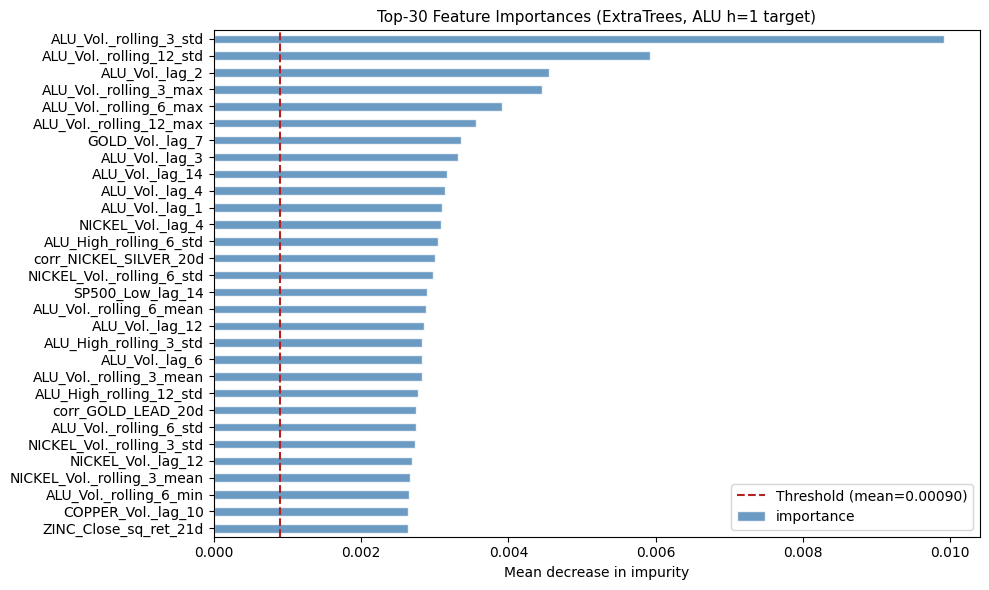


Top-10 features:
ALU_Vol._rolling_3_std     0.009908
ALU_Vol._rolling_12_std    0.005928
ALU_Vol._lag_2             0.004552
ALU_Vol._rolling_3_max     0.004459
ALU_Vol._rolling_6_max     0.003912
ALU_Vol._rolling_12_max    0.003566
GOLD_Vol._lag_7            0.003361
ALU_Vol._lag_3             0.003314
ALU_Vol._lag_14            0.003165
ALU_Vol._lag_4             0.003133


In [69]:
import time
import matplotlib.pyplot as plt
from sklearn.ensemble import ExtraTreesRegressor

print("Running feature selection (ExtraTrees on pre-test training data)...")
t0 = time.time()

# ALU h=1 as selection target — representative for all tasks
y_for_fs = all_targets[("ALU", 1)].reindex(X_all.index)

valid_fs = (
    X_all.notna().all(axis=1)        # no NaN in features
    & y_for_fs.notna()               # no NaN in target
    & (X_all.index < TEST_START)     # training period only
)
X_fs = X_all.loc[valid_fs]
y_fs = y_for_fs.loc[valid_fs]

print(f"  FS dataset : {X_fs.shape[0]} rows × {X_fs.shape[1]} features")

et = ExtraTreesRegressor(
    n_estimators=150, max_depth=10,
    max_features="sqrt", random_state=42, n_jobs=-1
)
et.fit(X_fs.values, y_fs.values)

importances = pd.Series(et.feature_importances_, index=all_feat_cols, name="importance")
threshold = importances.mean()
selected_cols = importances[importances >= threshold].sort_values(ascending=False).index.tolist()

print(f"  Threshold  : {threshold:.6f} (mean importance)")
print(f"  Selected   : {len(selected_cols)} / {len(all_feat_cols)} features  ({len(selected_cols)/len(all_feat_cols)*100:.0f}% retained)")
print(f"  Time       : {time.time()-t0:.1f}s")

# ── Update all downstream references ────────────────────────
all_feat_cols = selected_cols
X_all    = X_all[all_feat_cols].copy()
df_wfv   = X_all.loc[X_all.index < TEST_START]
df_test  = X_all.loc[X_all.index >= TEST_START]

# ── Plot top-30 feature importances ─────────────────────────
top30 = importances.sort_values(ascending=False).head(30)
fig, ax = plt.subplots(figsize=(10, 6))
top30[::-1].plot.barh(ax=ax, color="steelblue", alpha=0.8, edgecolor="white")
ax.axvline(threshold, color="firebrick", lw=1.5, ls="--", label=f"Threshold (mean={threshold:.5f})")
ax.set_title("Top-30 Feature Importances (ExtraTrees, ALU h=1 target)", fontsize=11)
ax.set_xlabel("Mean decrease in impurity")
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nTop-10 features:")
print(importances.sort_values(ascending=False).head(10).to_string())

# Walk-Forward Bootstrap Ensemble (Sklearn Baseline)

Schneller, interpretierbarer Baseline: **Ridge-Regression** mit Bootstrap-Ensemble über alle WFV-Folds.

Output pro Vorhersagepunkt:
- `mean` — Punkt-Vorhersage (Mittelwert der 5 Bootstrap-Modelle)
- `std`  — Unsicherheit (Std. der 5 Bootstrap-Modelle)
- `lower_95 / upper_95` — 95%-Konfidenzintervall

Evaluation-Metriken:
| Metrik | Bedeutung |
|---|---|
| MAE/RMSE | Punktgenauigkeit |
| Coverage@95 | Anteil der wahren Werte im 95%-KI (Ziel: ~95%) |
| AvgWidth | Mittlere KI-Breite (kleiner = schärfer) |
| CRPS | Probabilistischer Score (kleiner = besser) |

In [70]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from timeseries_forecast.trainer.ensemble import (
    run_walk_forward_bootstrap,
    evaluate_probabilistic,
)

TARGET_TASK    = "ALU"
TARGET_HORIZON = 1

# Feature matrix + target, aligned and cleaned
y_alu_h1 = all_targets[(TARGET_TASK, TARGET_HORIZON)]
joint = X_all.join(y_alu_h1.rename("target"), how="inner").dropna()
X_wfv_clean = joint[all_feat_cols].loc[joint.index < TEST_START]
y_wfv_clean = joint["target"].loc[joint.index < TEST_START]

print(f"WFV data: {len(X_wfv_clean)} rows  |  features: {X_wfv_clean.shape[1]}")

base_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge",  Ridge(alpha=1.0)),
])

print("\nRunning Walk-Forward Bootstrap Ensemble (5 models per fold)...")
wfv_result = run_walk_forward_bootstrap(
    X=X_wfv_clean,
    y=y_wfv_clean,
    base_model=base_model,
    splitter=splitter,
    n_models=5,
    verbose=True,
)

result_df = wfv_result.to_dataframe()
print(f"\nTotal WFV predictions: {len(result_df)}")

metrics_baseline = evaluate_probabilistic(
    y_true=result_df["y_true"].dropna().values,
    mean=result_df["mean"].loc[result_df["y_true"].notna()].values,
    std=result_df["std"].loc[result_df["y_true"].notna()].values,
    label="Ridge Bootstrap WFV (ALU h=1)",
)
print("\nAggregated Walk-Forward Metrics:")
print(metrics_baseline.to_string())

WFV data: 2901 rows  |  features: 441

Running Walk-Forward Bootstrap Ensemble (5 models per fold)...


Walk-forward folds: 100%|██████████| 31/31 [00:02<00:00, 11.12fold/s]


Total WFV predictions: 1953

Aggregated Walk-Forward Metrics:
MAE            0.008931
RMSE           0.012267
Coverage_95    0.657450
AvgWidth_95    0.022414
CRPS           0.006956


# Multi-Task Multi-Horizon LSTM

**Architektur:**
```
Input (batch, seq_len=21, n_features)
        ↓  LayerNorm
  Shared LSTM (2 Layer, hidden=64)
        ↓  Dropout
  Shared Projection (→ d_model=32, LayerNorm, GELU)
        ↓
  7 Tasks × 4 Horizonte = 28 unabhängige lineare Köpfe
        ↓
  Output (batch,) pro Kopf
```

**Training:**
- Loss: MSE gemittelt über alle 28 Köpfe (NaN-Targets werden maskiert)
- Early Stopping auf aggregiertem Val-Loss
- AdamW + ReduceLROnPlateau

**Unsicherheit:** MC-Dropout (Dropout bleibt bei Inference aktiv, 30 Passes)

In [ ]:
import torch
from timeseries_forecast.trainer.multi_task_models import (
    MultiTaskConfig,
    MultiTaskDataset,
    MultiTaskTrainer,
)

# ── Prepare aligned feature matrix for LSTM ─────────────────
# NaN-Imputation: use pre-test column means only → no test leakage
pretrain_mean = X_all.loc[X_all.index < TEST_START].mean()
X_lstm = X_all.copy().fillna(pretrain_mean)

# Align targets to X_lstm index
targets_aligned = {
    k: v.reindex(X_lstm.index)
    for k, v in all_targets.items()
    if k[0] in TASKS
}

# ── Last WFV fold boundaries for train/val split ─────────────
folds = splitter.get_folds(df_wfv)
last_fold = folds[-1]

def ts_to_pos(ts, idx):
    pos = idx.searchsorted(ts, side="right")
    return int(min(max(pos, 0), len(idx)))

train_end_pos  = ts_to_pos(last_fold.train_end, X_lstm.index)
val_end_pos    = ts_to_pos(last_fold.val_end,   X_lstm.index)
test_start_pos = ts_to_pos(pd.Timestamp(TEST_START), X_lstm.index)

SEQ_LEN = 21
WARMUP  = SEQ_LEN

def to_np(df_or_series):
    return df_or_series.values.astype("float32")

# Train
X_train_np = to_np(X_lstm.iloc[:train_end_pos])
t_train    = {k: to_np(v.iloc[:train_end_pos]) for k, v in targets_aligned.items()}

# Val with warmup
val_start  = max(0, train_end_pos - WARMUP)
X_val_np   = to_np(X_lstm.iloc[val_start:val_end_pos])
t_val      = {k: to_np(v.iloc[val_start:val_end_pos]) for k, v in targets_aligned.items()}

train_ds = MultiTaskDataset(X_train_np, t_train, seq_len=SEQ_LEN)
val_ds   = MultiTaskDataset(X_val_np,   t_val,   seq_len=SEQ_LEN)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
print(f"Train samples: {len(train_ds)}  |  Val samples: {len(val_ds)}")
print(f"Features: {X_train_np.shape[1]}  |  Tasks x Horizons: {len(TASKS)}x{len(HORIZONS)} = {len(TASKS)*len(HORIZONS)}")

# ── Konfiguration ────────────────────────────────────────────
# Groesseres Modell + laengeres Training mit OneCycleLR-Scheduler.
# OneCycleLR: 10% Warmup → cosine Decay auf lr/10000
# min_epochs=50 verhindert vorzeitiges Early Stopping in der Warmup-Phase
cfg = MultiTaskConfig(
    n_features    = X_train_np.shape[1],
    tasks         = TASKS,
    horizons      = HORIZONS,
    seq_len       = SEQ_LEN,
    hidden_dim    = 128,   # 64 → 128: doppelte Kapazitaet
    d_model       = 64,    # 32 → 64:  breitere Projektion
    n_lstm_layers = 2,
    dropout       = 0.20,  # etwas weniger Regularisierung
    lr            = 1e-4,  # niedriger → feinere Optimierung mit OneCycleLR
    weight_decay  = 1e-4,
    batch_size    = 32,    # kleinere Batches → mehr Gradientenschritte
    n_epochs      = 400,
    patience      = 60,    # 60 Epochen ohne Verbesserung → Stop
    min_epochs    = 50,    # nie vorher stoppen (Warmup-Phase schuetzen)
    min_delta     = 1e-6,
    device        = device,
)

print(f"\nTraining-Plan:")
print(f"  Epochen max:    {cfg.n_epochs}")
print(f"  Patience:       {cfg.patience} (ab Epoche {cfg.min_epochs})")
print(f"  Scheduler:      OneCycleLR  max_lr={cfg.lr:.0e}  warmup=10%")
print(f"  Modell-Params:  hidden={cfg.hidden_dim}, d_model={cfg.d_model}")

trainer = MultiTaskTrainer(cfg)
trainer.fit(train_ds, val_ds, verbose=True)


## MC-Dropout Unsicherheitsschätzung (Validierungsset)

30 stochastische Vorwärtspässe mit aktiviertem Dropout → Mean + Std als Proxy für epistemische Unsicherheit.

Running MC-Dropout (30 samples) on val set...
MAE            0.008638
RMSE           0.013127
Coverage_95    0.841270
AvgWidth_95    0.033380
CRPS           0.006741


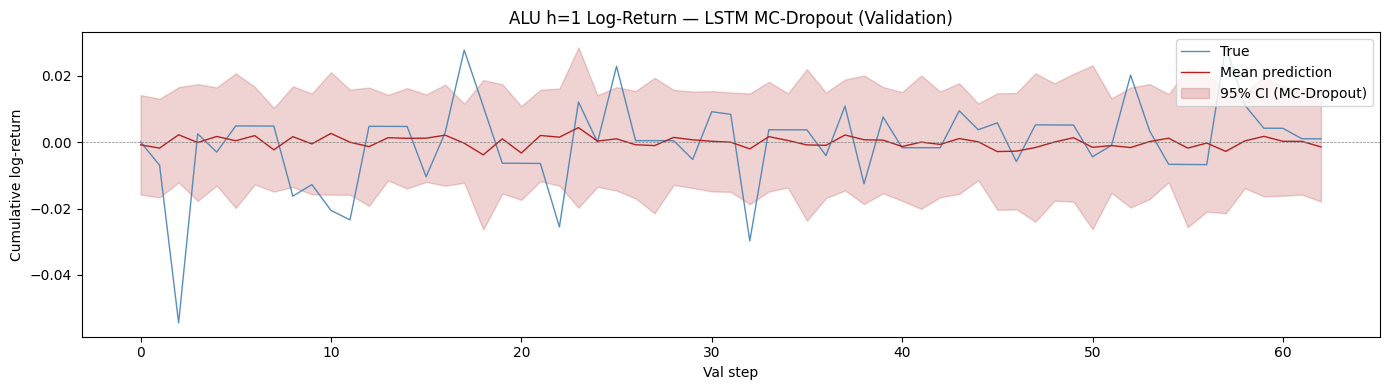


Coverage@95%: 84.1%  (target: ~95%)


In [72]:
import matplotlib.pyplot as plt
from timeseries_forecast.trainer.ensemble import evaluate_probabilistic, coverage_rate

MC_SAMPLES = 30
KEY = ("ALU", 1)   # Task + Horizon to visualise

# Build a single numpy array: last SEQ_LEN rows of train + full val
X_for_val = to_np(X_lstm.iloc[train_end_pos - SEQ_LEN : val_end_pos])

print(f"Running MC-Dropout ({MC_SAMPLES} samples) on val set...")
means_val, stds_val = trainer.predict_with_uncertainty(X_for_val, n_mc_samples=MC_SAMPLES)

# True targets for ALU h=1 in val window
y_val_true = targets_aligned[KEY].iloc[train_end_pos:val_end_pos].values

# Align lengths (valid predictions start after SEQ_LEN warm-up)
n_preds = len(means_val[KEY])
y_val_aligned = y_val_true[-n_preds:] if len(y_val_true) >= n_preds else y_val_true
pred_mean_val = means_val[KEY][-len(y_val_aligned):]
pred_std_val  = stds_val[KEY][-len(y_val_aligned):]

# Remove NaN rows (last h rows of target)
valid_mask = ~np.isnan(y_val_aligned)
metrics_lstm_val = evaluate_probabilistic(
    y_val_aligned[valid_mask], pred_mean_val[valid_mask], pred_std_val[valid_mask],
    label="LSTM MC-Dropout (Val, ALU h=1)"
)
print(metrics_lstm_val.to_string())

# ── Plot ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
x = range(len(y_val_aligned))
ax.plot(y_val_aligned, label="True", color="steelblue", lw=1, alpha=0.9)
ax.plot(pred_mean_val, label="Mean prediction", color="firebrick", lw=1)
ax.fill_between(
    x,
    pred_mean_val - 1.96 * pred_std_val,
    pred_mean_val + 1.96 * pred_std_val,
    alpha=0.2, color="firebrick", label="95% CI (MC-Dropout)"
)
ax.axhline(0, color="gray", lw=0.5, ls="--")
ax.set_title(f"ALU h=1 Log-Return — LSTM MC-Dropout (Validation)")
ax.set_ylabel("Cumulative log-return")
ax.set_xlabel("Val step")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

print(f"\nCoverage@95%: {metrics_lstm_val['Coverage_95']:.1%}  (target: ~95%)")

# Finales Test-Set Evaluation

**Einmal ausgeführt — kein weiteres Tuning danach!**

Zeigt Ergebnisse für:
1. Ridge Bootstrap Ensemble (Baseline) auf dem Test-Set
2. LSTM MC-Dropout auf dem Test-Set
3. Summary-Tabelle: alle 7 Metalle × 4 Horizonte

In [73]:
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
from timeseries_forecast.trainer.ensemble import (
    BootstrapEnsemble,
    evaluate_probabilistic,
    coverage_rate,
)

print("=" * 65)
print("FINAL TEST SET EVALUATION  (run only once — no tuning after this)")
print("=" * 65)

# ─────────────────────────────────────────────────────────────
# Helper
# ─────────────────────────────────────────────────────────────
def compute_metrics_row(y_true, y_pred, y_std, label):
    vm = ~np.isnan(y_true) & ~np.isnan(y_pred)
    yt, yp, ys = y_true[vm], y_pred[vm], y_std[vm]
    return {
        "Model":      label,
        "R²":         round(r2_score(yt, yp), 4),
        "MAE":        round(mean_absolute_error(yt, yp), 5),
        "RMSE":       round(root_mean_squared_error(yt, yp), 5),
        "Dir.Acc":    round(float((np.sign(yp) == np.sign(yt)).mean()), 3),
        "Cover.95":   round(coverage_rate(yt, yp, ys), 3),
    }

# ─────────────────────────────────────────────────────────────
# 1.  Ridge Bootstrap — train on ALL pre-test data, predict test
# ─────────────────────────────────────────────────────────────
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

y_alu_h1 = all_targets[("ALU", 1)]
joint_all = X_all.join(y_alu_h1.rename("target"), how="inner").dropna()

X_pretrain  = joint_all[all_feat_cols].loc[joint_all.index < TEST_START]
y_pretrain  = joint_all["target"].loc[joint_all.index < TEST_START]
X_test_skl  = joint_all[all_feat_cols].loc[joint_all.index >= TEST_START]
y_test_skl  = joint_all["target"].loc[joint_all.index >= TEST_START]

ridge_pipe  = Pipeline([("scaler", StandardScaler()), ("ridge", Ridge(alpha=1.0))])
ridge_final = BootstrapEnsemble(ridge_pipe, n_models=10, sample_frac=0.8)
ridge_final.fit(X_pretrain.values, y_pretrain.values, verbose=False)
ridge_mean, ridge_std = ridge_final.predict(X_test_skl.values)

# ─────────────────────────────────────────────────────────────
# 2.  LSTM MC-Dropout — test set
# ─────────────────────────────────────────────────────────────
test_warmup    = max(0, test_start_pos - SEQ_LEN)
X_for_test     = to_np(X_lstm.iloc[test_warmup:])
means_test, stds_test = trainer.predict_with_uncertainty(X_for_test, n_mc_samples=MC_SAMPLES)

# ─────────────────────────────────────────────────────────────
# 3.  Build metrics table
# ─────────────────────────────────────────────────────────────
rows_metrics = []

# Ridge (h=1 only)
rows_metrics.append(compute_metrics_row(y_test_skl.values, ridge_mean, ridge_std, "Ridge  h=1"))

# LSTM — all horizons
for h in HORIZONS:
    k = ("ALU", h)
    y_k  = targets_aligned[k].iloc[test_start_pos:].values
    p_k  = means_test[k]
    s_k  = stds_test[k]
    n    = min(len(p_k), len(y_k))
    rows_metrics.append(compute_metrics_row(y_k[-n:], p_k[-n:], s_k[-n:], f"LSTM   h={h:2d}"))

metrics_df = pd.DataFrame(rows_metrics).set_index("Model")
print("\n", metrics_df.to_string())
print("\nDir.Acc > 0.50 = better than random  |  Cover.95 ≈ 0.95 = well-calibrated CI")

FINAL TEST SET EVALUATION  (run only once — no tuning after this)



                  R²      MAE     RMSE  Dir.Acc  Cover.95
Model                                                   
Ridge  h=1  -0.6731  0.00863  0.01323    0.455     0.688
LSTM   h= 1  0.0043  0.00676  0.01021    0.511     0.908
LSTM   h= 5 -0.0510  0.01852  0.02441    0.483     0.732
LSTM   h=10 -0.0309  0.02639  0.03466    0.482     0.490
LSTM   h=21 -0.0795  0.03920  0.05144    0.503     0.560

Dir.Acc > 0.50 = better than random  |  Cover.95 ≈ 0.95 = well-calibrated CI


## Ergebnisvisualisierung

4 Panels:
- **A** Vorhersagen vs. Wahrheit auf dem Test-Set (h=1, LSTM + Ridge + 95%-KI)
- **B** R² nach Horizont — zeigt ob längere Horizonte tatsächlich besser sind
- **C** Metriktabelle mit Farbkodierung (grün = gut, rot = schlecht)
- **D** Directed Accuracy als Balkendiagramm (Grenze bei 50% = Random)

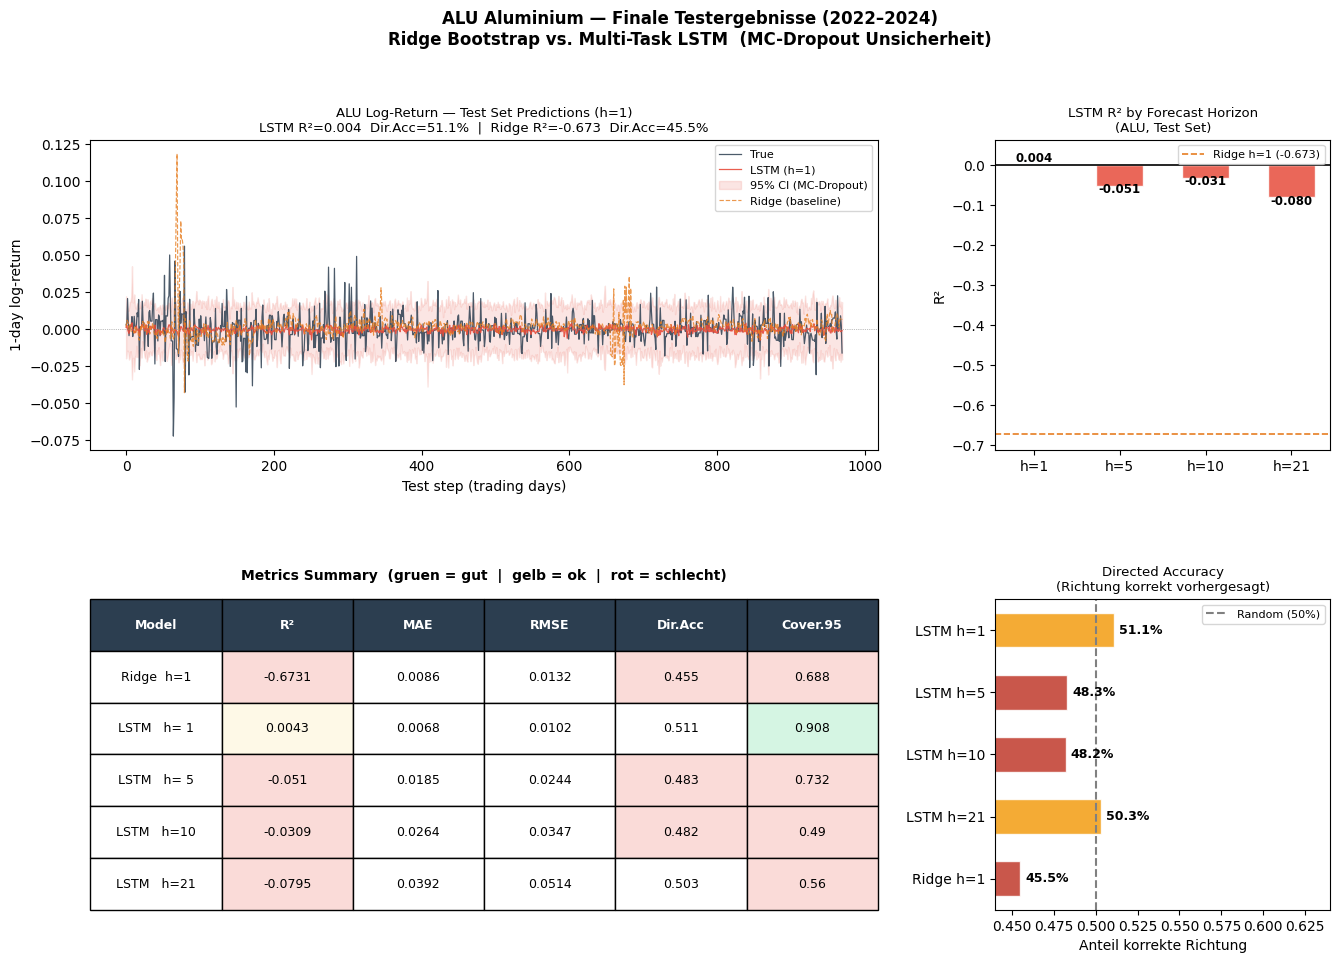

Gespeichert: results/final_test_evaluation.png


In [74]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os, warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────────────────────
# Align test predictions for the plots
# ─────────────────────────────────────────────────────────────
KEY_H1    = ("ALU", 1)
y_true_h1 = targets_aligned[KEY_H1].iloc[test_start_pos:].values
p_lstm_h1 = means_test[KEY_H1]
s_lstm_h1 = stds_test[KEY_H1]
n1        = min(len(p_lstm_h1), len(y_true_h1))
y_true_h1 = y_true_h1[-n1:]
p_lstm_h1 = p_lstm_h1[-n1:]
s_lstm_h1 = s_lstm_h1[-n1:]
n_ridge   = min(len(ridge_mean), n1)
valid_h1  = ~np.isnan(y_true_h1)

lstm_r2  = [metrics_df.loc[f"LSTM   h={h:2d}", "R\u00b2"]      for h in HORIZONS]
lstm_da  = [metrics_df.loc[f"LSTM   h={h:2d}", "Dir.Acc"] for h in HORIZONS]
ridge_r2 = metrics_df.loc["Ridge  h=1", "R\u00b2"]
ridge_da = metrics_df.loc["Ridge  h=1", "Dir.Acc"]

# ─────────────────────────────────────────────────────────────
# Figure
# ─────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.48, wspace=0.35)

# ── Panel A: Predictions vs True ─────────────────────────────
ax_a = fig.add_subplot(gs[0, :2])
x    = np.arange(n1)
ax_a.plot(x[valid_h1], y_true_h1[valid_h1],
          label="True", color="#2c3e50", lw=0.9, alpha=0.85)
ax_a.plot(x[valid_h1], p_lstm_h1[valid_h1],
          label="LSTM (h=1)", color="#e74c3c", lw=0.9, alpha=0.9)
ax_a.fill_between(
    x[valid_h1],
    (p_lstm_h1 - 1.96 * s_lstm_h1)[valid_h1],
    (p_lstm_h1 + 1.96 * s_lstm_h1)[valid_h1],
    alpha=0.14, color="#e74c3c", label="95% CI (MC-Dropout)"
)
ax_a.plot(
    x[-n_ridge:][valid_h1[-n_ridge:]],
    ridge_mean[-n1:][valid_h1[-n1:][-n_ridge:]],
    label="Ridge (baseline)", color="#e67e22", lw=0.85, ls="--", alpha=0.8
)
ax_a.axhline(0, color="gray", lw=0.5, ls=":")
ax_a.set_title(
    f"ALU Log-Return \u2014 Test Set Predictions (h=1)\n"
    f"LSTM R\u00b2={lstm_r2[0]:.3f}  Dir.Acc={lstm_da[0]:.1%}  |  "
    f"Ridge R\u00b2={ridge_r2:.3f}  Dir.Acc={ridge_da:.1%}",
    fontsize=9.5
)
ax_a.set_xlabel("Test step (trading days)")
ax_a.set_ylabel("1-day log-return")
ax_a.legend(fontsize=8, loc="upper right")

# ── Panel B: R² by horizon ───────────────────────────────────
ax_b = fig.add_subplot(gs[0, 2])
bar_colors = ["#e74c3c" if v < 0 else "#2980b9" for v in lstm_r2]
bars = ax_b.bar([f"h={h}" for h in HORIZONS], lstm_r2,
                color=bar_colors, alpha=0.85, edgecolor="white", width=0.55)
ax_b.axhline(0, color="black", lw=1.2)
ax_b.axhline(ridge_r2, color="#e67e22", lw=1.2, ls="--",
             label=f"Ridge h=1 ({ridge_r2:.3f})")
for bar, val in zip(bars, lstm_r2):
    offset = 0.005 if val >= 0 else -0.018
    ax_b.text(bar.get_x() + bar.get_width() / 2, val + offset,
              f"{val:.3f}", ha="center", fontsize=8.5, fontweight="bold")
ymin = min(min(lstm_r2) - 0.04, ridge_r2 - 0.04, -0.06)
ymax = max(max(lstm_r2) + 0.06, ridge_r2 + 0.06,  0.06)
ax_b.set_ylim(ymin, ymax)
ax_b.set_title("LSTM R\u00b2 by Forecast Horizon\n(ALU, Test Set)", fontsize=9.5)
ax_b.set_ylabel("R\u00b2")
ax_b.legend(fontsize=8)

# ── Panel C: Metrics table ───────────────────────────────────
ax_c = fig.add_subplot(gs[1, :2])
ax_c.axis("off")

tbl_data   = metrics_df.reset_index()
col_labels = list(tbl_data.columns)
cell_text  = tbl_data.round(4).astype(str).values.tolist()

table = ax_c.table(
    cellText=cell_text,
    colLabels=col_labels,
    cellLoc="center",
    loc="center",
    bbox=[0, 0, 1, 1],
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.7)

for j in range(len(col_labels)):
    table[(0, j)].set_facecolor("#2c3e50")
    table[(0, j)].set_text_props(color="white", fontweight="bold")

# Use .iloc to avoid namedtuple issues with special chars in column names
r2_col  = col_labels.index("R\u00b2")
da_col  = col_labels.index("Dir.Acc")
cov_col = col_labels.index("Cover.95")

for i in range(len(tbl_data)):
    r2_val  = tbl_data.iloc[i, r2_col]
    da_val  = tbl_data.iloc[i, da_col]
    cov_val = tbl_data.iloc[i, cov_col]

    if   r2_val >  0.05: table[(i + 1, r2_col)].set_facecolor("#d5f5e3")
    elif r2_val <  0.00: table[(i + 1, r2_col)].set_facecolor("#fadbd8")
    else:                table[(i + 1, r2_col)].set_facecolor("#fef9e7")

    if   da_val > 0.52:  table[(i + 1, da_col)].set_facecolor("#d5f5e3")
    elif da_val < 0.50:  table[(i + 1, da_col)].set_facecolor("#fadbd8")

    if   0.90 <= cov_val <= 0.98: table[(i + 1, cov_col)].set_facecolor("#d5f5e3")
    elif cov_val < 0.80:          table[(i + 1, cov_col)].set_facecolor("#fadbd8")

ax_c.set_title("Metrics Summary  (gruen = gut  |  gelb = ok  |  rot = schlecht)",
               fontweight="bold", fontsize=10, pad=14)

# ── Panel D: Directed Accuracy ───────────────────────────────
ax_d = fig.add_subplot(gs[1, 2])
labels_da = [f"LSTM h={h}" for h in HORIZONS] + ["Ridge h=1"]
vals_da   = lstm_da + [ridge_da]
colors_da = ["#27ae60" if v > 0.52 else ("#c0392b" if v < 0.50 else "#f39c12")
             for v in vals_da]
bars_da = ax_d.barh(labels_da[::-1], vals_da[::-1],
                    color=colors_da[::-1], alpha=0.85, edgecolor="white", height=0.55)
ax_d.axvline(0.50, color="gray", lw=1.5, ls="--", label="Random (50%)")
for bar, val in zip(bars_da, vals_da[::-1]):
    ax_d.text(val + 0.003, bar.get_y() + bar.get_height() / 2,
              f"{val:.1%}", va="center", fontsize=9, fontweight="bold")
ax_d.set_xlim(0.44, 0.64)
ax_d.set_title("Directed Accuracy\n(Richtung korrekt vorhergesagt)", fontsize=9.5)
ax_d.set_xlabel("Anteil korrekte Richtung")
ax_d.legend(fontsize=8)

fig.suptitle(
    "ALU Aluminium \u2014 Finale Testergebnisse (2022\u20132024)\n"
    "Ridge Bootstrap vs. Multi-Task LSTM  (MC-Dropout Unsicherheit)",
    fontsize=12, fontweight="bold", y=1.01
)

os.makedirs("../results", exist_ok=True)
plt.savefig("../results/final_test_evaluation.png", dpi=130, bbox_inches="tight")
plt.show()
print("Gespeichert: results/final_test_evaluation.png")
